# 📧 Email Spam Classification — NLP Pipeline

**Dataset:** SpamAssassin (5,796 emails — 3,900 ham / 1,896 spam)  
**Model:** Logistic Regression + TF-IDF (1,2)-grams + Hand-Crafted Features

### Key Design Decisions
| Concern | Solution |
|---|---|
| **Data Leakage** | Train/test split BEFORE feature fitting; `Pipeline` enforces fit-on-train-only |
| **Overfitting** | StratifiedKFold CV, L2 regularisation, learning curves, hold-out test set |
| **Class Imbalance** | `class_weight='balanced'` + stratified splits |

### Table of Contents
1. [Imports & Setup](#1)
2. [Load & Explore Data](#2)
3. [Text Preprocessing](#3)
4. [Hand-Crafted Feature Engineering](#4)
5. [Train / Test Split](#5)
6. [Combined Pipeline](#6)
7. [Cross-Validation](#7)
8. [Hyperparameter Tuning](#8)
9. [Learning Curves](#9)
10. [Final Evaluation](#10)
11. [Feature Importance](#11)
12. [Summary](#12)


---
## 1. Imports & Setup <a id='1'></a>

In [1]:
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline                import Pipeline
from sklearn.base                    import BaseEstimator, TransformerMixin
from sklearn.preprocessing           import StandardScaler
from sklearn.linear_model            import LogisticRegression
from sklearn.model_selection         import (
    train_test_split, StratifiedKFold,
    cross_validate, learning_curve, GridSearchCV,
)
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, ConfusionMatrixDisplay, roc_curve, auc,
)
from scipy.sparse import hstack, csr_matrix

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
SEED = 42
print('Imports ready ✅')


Imports ready ✅


---
## 2. Load & Explore Data <a id='2'></a>

In [2]:
df = pd.read_csv('../Files/spam_assassin.csv')

print('Shape   :', df.shape)
print('Columns :', df.columns.tolist())
print('Nulls:\n', df.isnull().sum())
df.head(3)


Shape   : (5796, 2)
Columns : ['text', 'target']
Nulls:
 text      0
target    0
dtype: int64


,text,target
0,From ilug-admin@linux.ie Mon Jul 29 11:28:02 2...,0
1,From gort44@excite.com Mon Jun 24 17:54:21 200...,1
2,From fork-admin@xent.com Mon Jul 29 11:39:57 2...,1


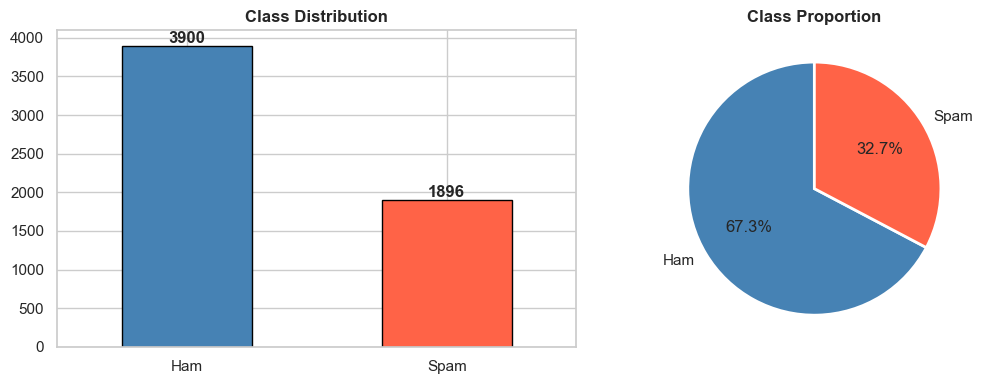

⚠️  Imbalanced — using stratified splits + class_weight="balanced"


In [3]:
# Label distribution
label_map = {0: 'Ham', 1: 'Spam'}
df['label'] = df['target'].map(label_map)
counts = df['label'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

counts.plot(kind='bar', ax=axes[0], color=['steelblue', 'tomato'], edgecolor='black')
axes[0].set_title('Class Distribution', fontweight='bold')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=0)
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}',
                     (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontweight='bold')

axes[1].pie(counts, labels=counts.index, autopct='%1.1f%%',
            colors=['steelblue', 'tomato'], startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Class Proportion', fontweight='bold')

plt.tight_layout()
plt.show()
print('⚠️  Imbalanced — using stratified splits + class_weight="balanced"')


      char_count                                                           \
           count    mean     std    min     25%     50%     75%       max   
label                                                                       
Ham       3900.0  3483.1  3134.1  362.0  2435.2  3196.5  4049.2   92469.0   
Spam      1896.0  5667.1  9068.5  736.0  2391.8  3824.0  6304.0  232305.0   

      word_count                                                    
           count   mean    std   min    25%    50%    75%      max  
label                                                               
Ham       3900.0  405.7  484.9  45.0  262.0  347.0  454.0  15164.0  
Spam      1896.0  545.6  612.2  73.0  250.0  386.0  617.2  11857.0  


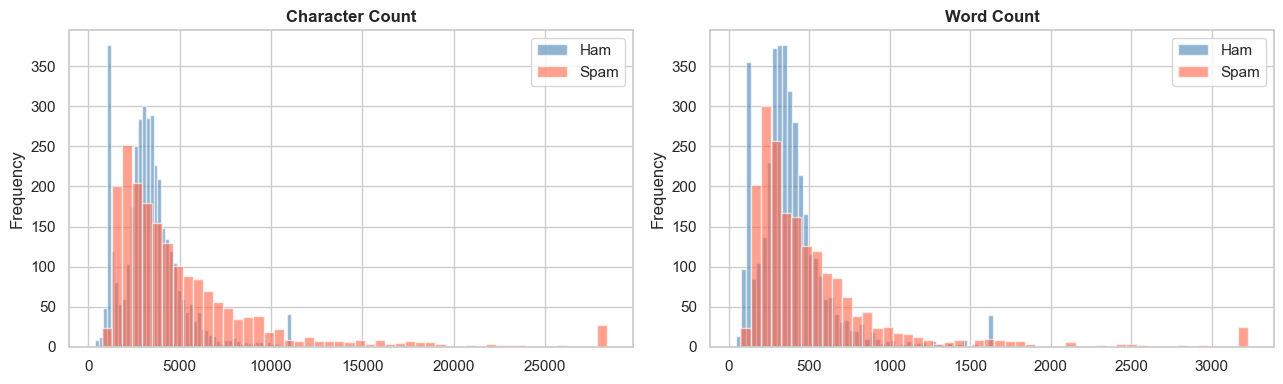

In [4]:
# Email length by class
df['char_count'] = df['text'].str.len()
df['word_count'] = df['text'].str.split().str.len()

print(df.groupby('label')[['char_count', 'word_count']].describe().round(1))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, col, title in zip(axes,
                           ['char_count', 'word_count'],
                           ['Character Count', 'Word Count']):
    for lbl, color in [('Ham', 'steelblue'), ('Spam', 'tomato')]:
        subset = df[df['label'] == lbl][col]
        subset.clip(upper=subset.quantile(0.99)).plot(
            kind='hist', bins=50, ax=ax, alpha=0.6,
            color=color, label=lbl, edgecolor='white')
    ax.set_title(title, fontweight='bold')
    ax.legend()

plt.tight_layout()
plt.show()

df.drop(columns=['char_count', 'word_count', 'label'], inplace=True)


---
## 3. Text Preprocessing <a id='3'></a>

> Purely rule-based — no statistics learned. Safe to apply before the split.


In [5]:
def preprocess_email(text: str) -> str:
    if not isinstance(text, str):
        return ''
    text = text.lower()
    # Remove email headers
    text = re.sub(r'^(from|subject|to|cc|bcc|received|content-type|mime-version|'
                  r'message-id|return-path|delivered-to|x-[a-z-]+):.*$',
                  '', text, flags=re.MULTILINE | re.IGNORECASE)
    text = re.sub(r'https?://\S+|www\.\S+', ' url ', text)   # URLs
    text = re.sub(r'[\w.+-]+@[\w-]+\.[\w.-]+', ' email ', text) # emails
    text = re.sub(r'\$\s*\d+[\d,.]*', ' money ', text)          # currency
    text = re.sub(r'\b(\+?\d[\s.-]?){7,15}\b', ' phone ', text) # phones
    text = re.sub(r'<[^>]+>', ' ', text)                          # HTML tags
    text = re.sub(r'[^a-z\s]', ' ', text)                        # non-alpha
    text = re.sub(r'\s+', ' ', text).strip()
    return text


df['clean_text'] = df['text'].apply(preprocess_email)

print('Sample — Original:')
print(df['text'].iloc[1][:250])
print('\nSample — Cleaned:')
print(df['clean_text'].iloc[1][:250])


Sample — Original:
From gort44@excite.com Mon Jun 24 17:54:21 2002 Return-Path: gort44@excite.com Delivery-Date: Tue Jun 4 05:31:16 2002 Received: from mandark.labs.netnoteinc.com ([213.105.180.140]) by dogma.slashnull.org (8.11.6/8.11.6) with ESMTP id g544VFO20182 for

Sample — Cleaned:
from email mon jun return path email delivery date tue jun received from mandark labs netnoteinc com phone by dogma slashnull org with esmtp id g vfo for tue jun received from wi poli poli cl phone by mandark labs netnoteinc com with smtp id g vc tue


---
## 4. Hand-Crafted Feature Engineering <a id='4'></a>

> Stateless features — no corpus statistics learned. Safe before the split.

| Feature | Spam signal |
|---|---|
| `caps_ratio` | ALL CAPS shouting |
| `exclamation_count` | Urgency punctuation `!!!` |
| `url_count` | Phishing / affiliate links |
| `dollar_count` | Money promises |
| `html_flag` | Bulk HTML emails |
| `word_count` | Verbose spam |
| `avg_word_length` | Gibberish padding |
| `digit_ratio` | Phone numbers, tracking codes |
| `unique_word_ratio` | Low ratio → repetitive spam |


In [6]:
def extract_features(series: pd.Series) -> pd.DataFrame:
    raw = series.fillna('')
    words = raw.str.split()
    return pd.DataFrame({
        'caps_ratio'       : raw.apply(lambda t: sum(c.isupper() for c in t) / max(len(t), 1)),
        'exclamation_count': raw.str.count(r'!'),
        'url_count'        : raw.str.count(r'https?://|www\.'),
        'dollar_count'     : raw.str.count(r'\$'),
        'html_flag'        : raw.str.contains(r'<html|<body|<table|<td|<font',
                                              case=False, regex=True).astype(int),
        'word_count'       : words.str.len().fillna(0),
        'avg_word_length'  : words.apply(
                                lambda ws: np.mean([len(w) for w in ws])
                                if isinstance(ws, list) and ws else 0),
        'digit_ratio'      : raw.apply(lambda t: sum(c.isdigit() for c in t) / max(len(t), 1)),
        'unique_word_ratio': words.apply(
                                lambda ws: len(set(ws)) / max(len(ws), 1)
                                if isinstance(ws, list) and ws else 0),
    }, index=series.index).astype(float)


feat_df = extract_features(df['text'])
df = pd.concat([df, feat_df], axis=1)
HAND_FEAT_COLS = feat_df.columns.tolist()

print('Hand-crafted features:', HAND_FEAT_COLS)
print()
print(feat_df.describe().round(3).to_string())


Hand-crafted features: ['caps_ratio', 'exclamation_count', 'url_count', 'dollar_count', 'html_flag', 'word_count', 'avg_word_length', 'digit_ratio', 'unique_word_ratio']

       caps_ratio  exclamation_count  url_count  dollar_count  html_flag  word_count  avg_word_length  digit_ratio  unique_word_ratio
count    5796.000           5796.000   5796.000      5796.000   5796.000    5796.000         5796.000     5796.000           5796.000
mean        0.075              2.578      6.277         1.751      0.180     451.448            8.513        0.104              0.636
std         0.051              6.854     19.346         8.594      0.384     533.936            3.429        0.032              0.078
min         0.019              0.000      0.000         0.000      0.000      45.000            4.095        0.005              0.150
25%         0.054              0.000      2.000         0.000      0.000     258.750            7.121        0.085              0.598
50%         0.063        

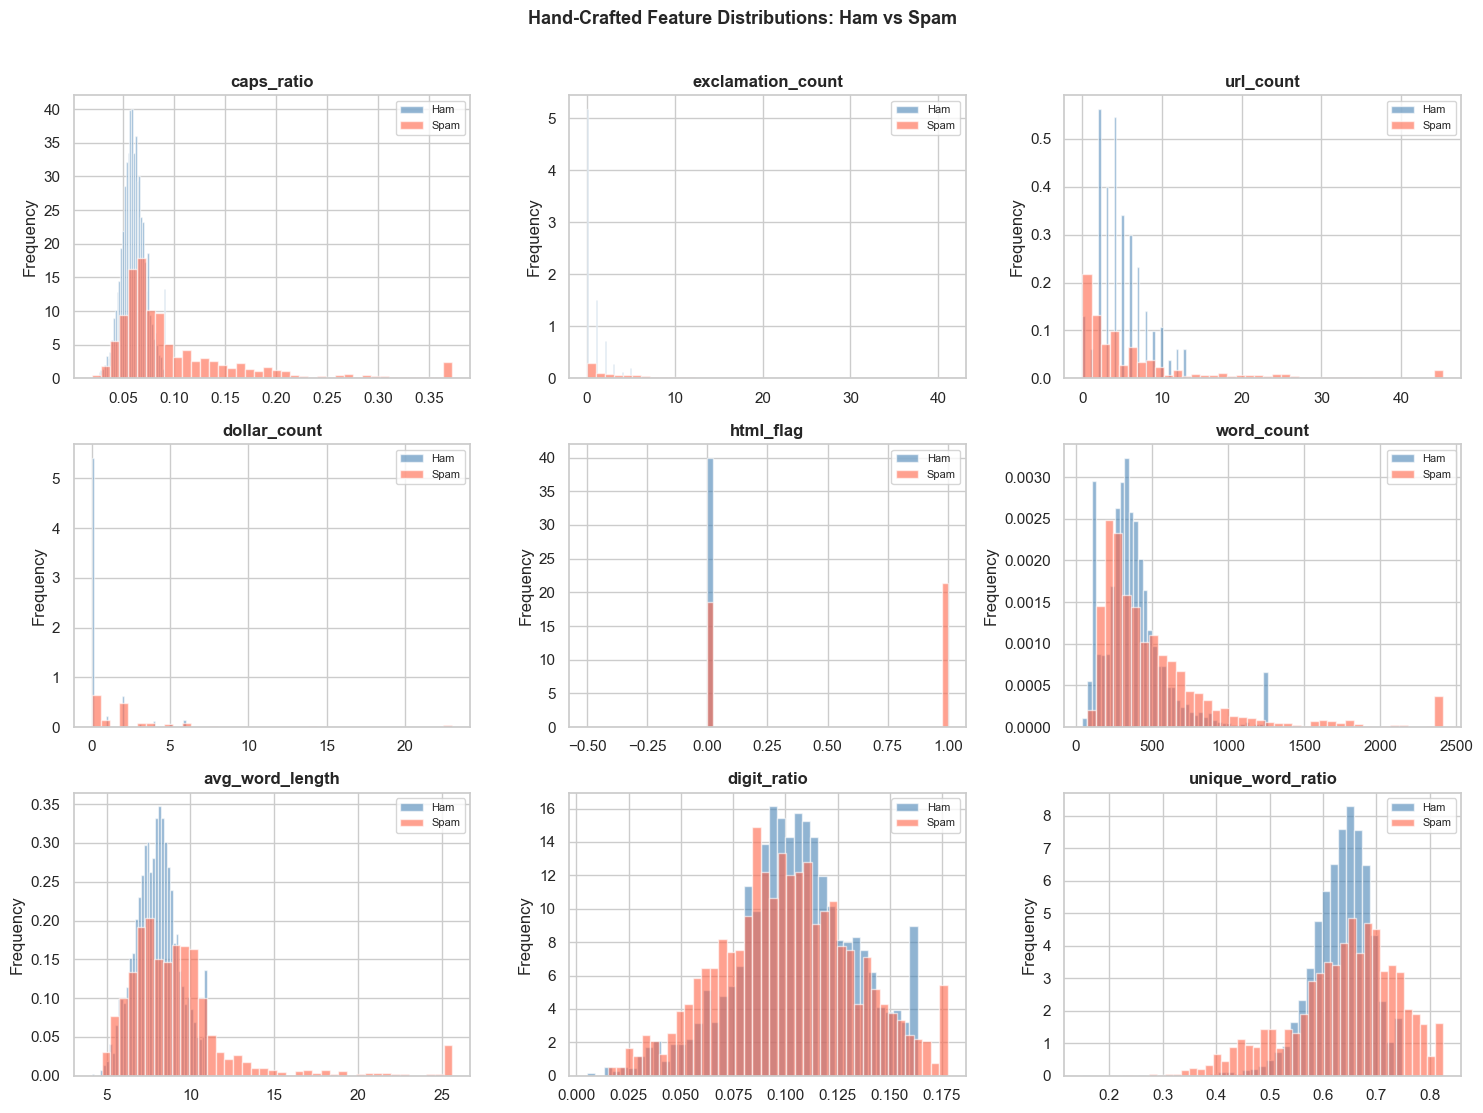

Feature distributions plotted ✅


In [7]:
# Distribution: Ham vs Spam for each feature
label_map = {0: 'Ham', 1: 'Spam'}
df['_label'] = df['target'].map(label_map)

fig, axes = plt.subplots(3, 3, figsize=(15, 11))
axes = axes.flatten()

for ax, col in zip(axes, HAND_FEAT_COLS):
    for lbl, color in [('Ham', 'steelblue'), ('Spam', 'tomato')]:
        subset = df[df['_label'] == lbl][col]
        subset.clip(upper=subset.quantile(0.98)).plot(
            kind='hist', bins=40, ax=ax, alpha=0.6,
            color=color, label=lbl, edgecolor='white', density=True)
    ax.set_title(col, fontweight='bold')
    ax.legend(fontsize=8)

plt.suptitle('Hand-Crafted Feature Distributions: Ham vs Spam',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

df.drop(columns=['_label'], inplace=True)
print('Feature distributions plotted ✅')
